[<< Sommaire QC](../README.md) | [Precedent : QC-Py-30-LSTM-Training <<](./QC-Py-30-LSTM-Training.ipynb) | [Suivant : QC-Py-33-RL-PPO-Trading >>](./QC-Py-33-RL-PPO-Trading.ipynb)

# QC-Py-32 - Reinforcement Learning DQN pour le Trading

> **Niveau** : Avance | **Pre-requis** : QC-Py-22, QC-Py-30 | **Temps** : 120 min

> **Objectif** : Entrainer un agent DQN (Deep Q-Network) avec un environnement
> de trading realiste incluant frais, slippage et impact marche, sur des donnees
> S&P 500 multi-actifs.

> **[REFERENCE QC Cloud]** Ce notebook demontre l'entrainement d'un agent RL (DQN double)
> avec un environnement de trading realiste. L'agent apprend une politique d'achat/vente
> en interagissant avec un marche simule.
>
> **Mode d'emploi** : Ce notebook a **quatre parties** :
> 1. **Environnement** : Marche simule avec frais, slippage, impact marche
> 2. **Agent DQN** : Double DQN avec replay buffer et epsilon-greedy
> 3. **Entrainement** : Boucle RL avec evaluation periodique
> 4. **Integration QC** : Deploiement sur QuantConnect via ObjectStore

---

## Partie 1 : Environnement de Trading Realiste (25 min)

### Pourquoi un Environnement Realiste ?

Un environnement de trading RL doit modeliser les frictions du marche reel.
Sans ces frictions, l'agent apprend des strategies impossibles a executer en production.

**Frictions modelisees** :
- **Frais de transaction** : 10 bps par trade (0.1%)
- **Slippage** : 5 bps supplementaires (modele lineaire)
- **Impact marche** : Proportionnel au volume trade / volume quotidien moyen
- **Short selling** : Autorise avec cout d'emprunt (2% annualise)
- **Cash constraint** : Pas de levier, positions limitees au capital

**Espace d'observation** (par actif) :
- Prix normalise (rendement cumule depuis debut)
- Rendements (1j, 5j, 20j)
- Volatilite roulee (20j)
- Position courante (normalisee)
- Ratio volume / volume moyen

**Espace d'action** :
- 0 : Ne rien faire (hold)
- 1 : Acheter (long 10% du capital)
- 2 : Vendre (short 10% du capital)
- 3 : Fermer la position

---

### Implementation de l'Environnement

In [2]:
# Imports standards
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")


PyTorch version: 2.11.0+cu128


CUDA available: True
GPU: NVIDIA GeForce RTX 3070 Laptop GPU
VRAM: 8.6 GB
Device: cuda


### Interpretation

PyTorch detecte le GPU. L'entrainement DQN beneficie du GPU pour les passes
avant des reseaux Q, mais le bottleneck principal est la simulation de
l'environnement (CPU).

In [3]:
# Telechargement des donnees
import yfinance as yf
from datetime import datetime

TRADE_TICKERS = [
    "AAPL", "MSFT", "NVDA", "AMZN", "GOOGL",
    "META", "JPM", "V", "UNH", "XOM",
    "MA", "JNJ", "PG", "HD", "MRK"
]

END_DATE = datetime(2025, 1, 1)
START_DATE = datetime(2014, 1, 1)
VAL_START = datetime(2022, 1, 1)

print(f"Telechargement de {len(TRADE_TICKERS)} actions...")
data = yf.download(TRADE_TICKERS, start=START_DATE, end=END_DATE, auto_adjust=True)
close_prices = data["Close"].dropna(axis=1, how="all")
volume_data = data["Volume"].dropna(axis=1, how="all")
valid_tickers = [t for t in TRADE_TICKERS if t in close_prices.columns]
print(f"Tickers valides: {len(valid_tickers)}/{len(TRADE_TICKERS)}")
print(f"Periode: {close_prices.index[0].strftime('%Y-%m-%d')} au {close_prices.index[-1].strftime('%Y-%m-%d')}")
print(f"Jours de bourse: {len(close_prices)}")


Telechargement de 15 actions...


[                       0%                       ]

[                       0%                       ]

[**********            20%                       ]  3 of 15 completed

[*************         27%                       ]  4 of 15 completed

...

[**********************80%*************          ]  12 of 15 completed

[**********************80%*************          ]  12 of 15 completed

[**********************93%********************   ]  14 of 15 completed

[*********************100%***********************]  15 of 15 completed

Tickers valides: 15/15
Periode: 2014-01-02 au 2024-12-31
Jours de bourse: 2768


### Interpretation

15 actions liquides S&P 500 sur 11 ans. Le split temporel utilise 2014-2021
pour l'entrainement et 2022-2024 pour la validation (pas de leak de donnees).

In [4]:
# Environnement de trading realiste
class TradingEnvironment:
    """Environnement de trading RL avec frictions realistes."""

    def __init__(self, prices, volumes, initial_cash=100000, commission_bps=10,
                 slippage_bps=5, impact_coeff=0.1, borrow_cost=0.02):
        self.prices = prices.values if hasattr(prices, 'values') else prices
        self.volumes = volumes.values if hasattr(volumes, 'values') else volumes
        self.n_assets = self.prices.shape[1]
        self.initial_cash = initial_cash
        self.commission_rate = commission_bps / 10000
        self.slippage_rate = slippage_bps / 10000
        self.impact_coeff = impact_coeff
        self.borrow_cost = borrow_cost / 252
        self.n_actions = 4
        self.reset()

    def reset(self):
        self.cash = self.initial_cash
        self.positions = np.zeros(self.n_assets)
        self.cost_basis = np.zeros(self.n_assets)
        self.current_step = 0
        self.total_steps = len(self.prices) - 1
        self.portfolio_values = [self.initial_cash]
        self.returns = []
        self.trades_log = []
        return self._get_observation()

    def _get_observation(self):
        t = self.current_step
        lookback = min(t, 20)
        obs = []
        for i in range(self.n_assets):
            price_series = self.prices[t-lookback:t+1, i]
            if len(price_series) < 2 or price_series[-2] == 0:
                obs.extend([0.0] * 6)
                continue
            ret_1d = (price_series[-1] / price_series[-2]) - 1 if len(price_series) >= 2 else 0
            ret_5d = (price_series[-1] / price_series[-5]) - 1 if len(price_series) >= 5 else 0
            ret_20d = (price_series[-1] / price_series[0]) - 1
            vol_20d = np.std(np.diff(price_series) / price_series[:-1]) if len(price_series) >= 3 else 0.01
            pos_norm = self.positions[i] * self.prices[t, i] / self.initial_cash
            vol_ratio = 1.0
            if t < len(self.volumes) and self.volumes[t, i] > 0:
                avg_vol = np.mean(self.volumes[max(0, t-20):t+1, i])
                if avg_vol > 0:
                    vol_ratio = self.volumes[t, i] / avg_vol
            obs.extend([ret_1d, ret_5d, ret_20d, vol_20d, pos_norm, vol_ratio])
        return np.array(obs, dtype=np.float32)

    @property
    def observation_dim(self):
        return self.n_assets * 6

    def step(self, actions):
        t = self.current_step
        if t >= self.total_steps:
            return self._get_observation(), 0, True, {}

        old_value = self._portfolio_value(t)
        trade_amount = self.initial_cash * 0.10

        for i, action in enumerate(actions):
            price = self.prices[t, i]
            if price <= 0:
                continue
            avg_vol = np.mean(self.volumes[max(0, t-20):t+1, i]) if t < len(self.volumes) else 1e6
            shares_to_trade = trade_amount / price
            vol_impact = self.impact_coeff * (shares_to_trade / max(avg_vol, 1))
            exec_price = price * (1 + vol_impact)

            if action == 1:
                cost = exec_price * shares_to_trade * (1 + self.commission_rate + self.slippage_rate)
                if cost <= self.cash:
                    self.cash -= cost
                    self.positions[i] += shares_to_trade
                    self.cost_basis[i] = exec_price
                    self.trades_log.append({"step": t, "ticker": i, "action": "BUY", "price": exec_price})
            elif action == 2:
                if self.positions[i] > 0:
                    proceeds = exec_price * self.positions[i] * (1 - self.commission_rate - self.slippage_rate)
                    self.cash += proceeds
                    self.trades_log.append({"step": t, "ticker": i, "action": "SELL", "price": exec_price})
                    self.positions[i] = 0
                    self.cost_basis[i] = 0
                else:
                    shares = trade_amount / exec_price
                    borrow_cost = exec_price * shares * self.borrow_cost
                    proceeds = exec_price * shares * (1 - self.commission_rate - self.slippage_rate) - borrow_cost
                    self.cash += proceeds
                    self.positions[i] -= shares
                    self.trades_log.append({"step": t, "ticker": i, "action": "SHORT", "price": exec_price})
            elif action == 3:
                if self.positions[i] != 0:
                    if self.positions[i] > 0:
                        proceeds = exec_price * abs(self.positions[i]) * (1 - self.commission_rate - self.slippage_rate)
                    else:
                        proceeds = -exec_price * abs(self.positions[i]) * (1 + self.commission_rate + self.slippage_rate)
                    self.cash += proceeds
                    self.trades_log.append({"step": t, "ticker": i, "action": "CLOSE", "price": exec_price})
                    self.positions[i] = 0
                    self.cost_basis[i] = 0

        for i in range(self.n_assets):
            if self.positions[i] < 0:
                self.cash -= abs(self.positions[i]) * self.prices[t, i] * self.borrow_cost

        self.current_step += 1
        new_value = self._portfolio_value(self.current_step)
        reward = (new_value - old_value) / old_value * 100
        self.portfolio_values.append(new_value)
        self.returns.append(reward)
        done = self.current_step >= self.total_steps or new_value < self.initial_cash * 0.5
        info = {"portfolio_value": new_value, "n_trades": len(self.trades_log)}
        return self._get_observation(), reward, done, info

    def _portfolio_value(self, t):
        if t >= len(self.prices):
            t = len(self.prices) - 1
        asset_value = np.sum(self.positions * self.prices[t])
        return self.cash + asset_value


split_idx = close_prices.index.get_loc(close_prices[close_prices.index >= VAL_START].index[0])
train_prices = close_prices.iloc[:split_idx].values.astype(np.float64)
train_volumes = volume_data.iloc[:split_idx].values.astype(np.float64)
val_prices = close_prices.iloc[split_idx:].values.astype(np.float64)
val_volumes = volume_data.iloc[split_idx:].values.astype(np.float64)

train_env = TradingEnvironment(train_prices, train_volumes)
val_env = TradingEnvironment(val_prices, val_volumes)

print(f"Environnement cree:")
print(f"  Actifs: {train_env.n_assets}")
print(f"  Observation dim: {train_env.observation_dim}")
print(f"  Actions: {train_env.n_actions} (Hold/Buy/Sell/Close)")
print(f"  Train steps: {train_env.total_steps}")
print(f"  Val steps: {val_env.total_steps}")
print(f"  Frais: {train_env.commission_rate*10000:.0f} bps + {train_env.slippage_rate*10000:.0f} bps slippage")
print(f"  Impact marche: coeff={train_env.impact_coeff}")
print(f"  Cout emprunt short: {train_env.borrow_cost*252*100:.1f}% annualise")


Environnement cree:
  Actifs: 15
  Observation dim: 90
  Actions: 4 (Hold/Buy/Sell/Close)
  Train steps: 2014
  Val steps: 752
  Frais: 10 bps + 5 bps slippage
  Impact marche: coeff=0.1
  Cout emprunt short: 2.0% annualise


### Exercice 1 : Modifier la fonction de recompense

La recompense actuelle utilise le return net. Modifiez-la pour utiliser un **return ajuste au risque** : recompense = return - 0.5 * volatility (penalise la volatilite excessive).

**Indices** :
- `# Indice` : La recompense est calculee dans la methode `step()` de `TradingEnvironment`
- `# Indice` : La volatilite peut etre mesuree comme l'ecart-type des N derniers returns
- `# Etape 1` : Identifier ou la recompense est calculee dans `step()`
- `# Etape 2` : Ajouter un terme de penalite de volatilite
- `# Etape 3` : Observer le changement de comportement de l'agent

In [5]:
# Exercice 1 : Recompense ajustee au risque
# TODO etudiant : Modifier la recompense pour penaliser la volatilite
# Etape 1 : Identifier la recompense dans step()
# Etape 2 : Ajouter -0.5 * vol_recente
# Etape 3 : Comparer le comportement
reward_adj = None  # TODO etudiant : remplacer par le calcul
print("Exercice a completer : Recompense ajustee au risque")

Exercice a completer : Recompense ajustee au risque


### Interpretation

L'environnement simule les frictions d'un marche reel. Chaque action trade 10%
du capital. L'impact marche est proportionnel au volume trade relativement au
volume quotidien moyen. Les positions courtes coutent 2% annualise en emprunt.

---

## Partie 2 : Agent DQN Double avec Replay Buffer (25 min)

### Double DQN



Le Double DQN corrige la surestimation des Q-values du DQN classique.



**DQN classique** : `Q_target = r + gamma * max_a Q_target(s', a)`

**Double DQN** : `Q_target = r + gamma * Q_target(s', argmax_a Q_online(s', a))`



Le reseau online selectionne l'action, le reseau cible evalue la Q-value.

Cela reduit le biais d'optimisme et stabilise l'apprentissage.



**Composants** :

- **Replay buffer** : 100K transitions, echantillonnage uniforme

- **Target network** : Update soft (tau=0.005) vers le reseau online

- **Epsilon-greedy** : Decay exponentiel de 1.0 a 0.05 sur 50K pas

- **Gradient clipping** : max_norm=10 pour stabilite

> *Ancre savante -- van Hasselt, H., Guez, A. & Silver, D. (2016), « Deep Reinforcement Learning with Double Q-learning », AAAI Conference on Artificial Intelligence, arXiv:1509.06461. Origine du Double DQN (decouplage selection/evaluation de l'action pour reduire la surestimation des Q-values). Voir aussi References academiques.*


In [6]:
# Replay Buffer
import random
from collections import deque

class ReplayBuffer:
    """Experience replay buffer pour DQN."""
    def __init__(self, capacity=100000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (np.array(states), np.array(actions), np.array(rewards),
                np.array(next_states), np.array(dones, dtype=np.float32))

    def __len__(self):
        return len(self.buffer)


# Reseaux Q (online + target)
import torch.nn as nn
import torch.nn.functional as F

class QNetwork(nn.Module):
    """Reseau Q pour DQN avec architecture dueling."""
    def __init__(self, state_dim, action_dim, hidden_dim=256):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.BatchNorm1d(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.BatchNorm1d(hidden_dim),
        )
        self.value_stream = nn.Sequential(
            nn.Linear(hidden_dim, 128), nn.ReLU(), nn.Linear(128, 1)
        )
        self.advantage_stream = nn.Sequential(
            nn.Linear(hidden_dim, 128), nn.ReLU(), nn.Linear(128, action_dim)
        )

    def forward(self, x):
        shared = self.shared(x)
        value = self.value_stream(shared)
        advantage = self.advantage_stream(shared)
        return value + advantage - advantage.mean(dim=1, keepdim=True)


STATE_DIM = 6  # Per-asset state dimension (6 features per asset)
ACTION_DIM = train_env.n_actions

q_online = QNetwork(STATE_DIM, ACTION_DIM, hidden_dim=256).to(DEVICE)
q_target = QNetwork(STATE_DIM, ACTION_DIM, hidden_dim=256).to(DEVICE)
q_target.load_state_dict(q_online.state_dict())

n_params = sum(p.numel() for p in q_online.parameters())
print(f"QNetwork (Dueling DQN):")
print(f"  State dim: {STATE_DIM} (per-asset) | Full obs: {train_env.observation_dim} ({train_env.n_assets} assets x 6 features)")
print(f"  Action dim: {ACTION_DIM} (Hold/Buy/Sell/Close)")
print(f"  Hidden dim: 256")
print(f"  Architecture: Dueling (Value + Advantage)")
print(f"  Parametres: {n_params:,}")
print(f"  Device: {DEVICE}")


QNetwork (Dueling DQN):
  State dim: 6 (per-asset) | Full obs: 90 (15 assets x 6 features)
  Action dim: 4 (Hold/Buy/Sell/Close)
  Hidden dim: 256
  Architecture: Dueling (Value + Advantage)
  Parametres: 135,045
  Device: cuda


### Exercice 2 : Implementer un epsilon schedule lineaire

Le code utilise un epsilon fixe pour l'exploration. Implementez un **epsilon schedule lineaire** : epsilon passe de 1.0 a 0.01 sur les 80% premiers pas d'apprentissage.

**Indices** :
- `# Indice` : `epsilon = max(0.01, 1.0 - step / (0.8 * total_steps))`
- `# Etape 1` : Definir total_steps et calculer le seuil de decay
- `# Etape 2` : Implementer la formule lineaire
- `# Etape 3` : Verifier que epsilon decroit correctement

In [7]:
# Exercice 2 : Epsilon schedule lineaire
# TODO etudiant : Implementer un epsilon qui decroit lineairement de 1.0 a 0.01
# Etape 1 : Definir total_steps = 100000 et decay_steps = 0.8 * total_steps
# Etape 2 : epsilon = max(0.01, 1.0 - step / decay_steps)
# Etape 3 : Verifier en affichant epsilon a differents steps
epsilon_schedule = None  # TODO etudiant : remplacer par le calcul
print("Exercice a completer : Epsilon schedule lineaire")

Exercice a completer : Epsilon schedule lineaire


### Interpretation



L'architecture Dueling DQN separe l'estimation de la valeur d'etat et de l'avantage

par action. Cela permet au reseau d'apprendre quelles actions sont importantes

sans avoir a calculer la valeur de chaque action pour chaque etat.



- **Value stream** : Estime la valeur de l'etat (combien vaut cette situation de marche)

- **Advantage stream** : Estime l'avantage de chaque action relative a la moyenne

> *Ancre savante -- Wang, Z., Schaul, T., Hessel, M. et al. (2016), « Dueling Network Architectures for Deep Reinforcement Learning », ICML, arXiv:1511.06581. Origine de l'architecture Dueling (decomposition Q(s,a) = V(s) + A(s,a) separant valeur d'etat et avantage de l'action). Voir aussi References academiques.*


In [8]:
# Agent DQN complet
class DQNAgent:
    """Agent DQN double avec epsilon-greedy et soft update."""

    def __init__(self, state_dim, action_dim, hidden_dim=256,
                 lr=1e-4, gamma=0.99, tau=0.005,
                 epsilon_start=1.0, epsilon_end=0.05, epsilon_decay=50000,
                 buffer_capacity=100000, batch_size=128):
        self.action_dim = action_dim
        self.gamma = gamma
        self.tau = tau
        self.batch_size = batch_size
        self.epsilon = epsilon_start
        self.epsilon_end = epsilon_end
        self.epsilon_decay = epsilon_decay
        self.total_steps = 0

        self.q_online = QNetwork(state_dim, action_dim, hidden_dim).to(DEVICE)
        self.q_target = QNetwork(state_dim, action_dim, hidden_dim).to(DEVICE)
        self.q_target.load_state_dict(self.q_online.state_dict())
        self.optimizer = torch.optim.AdamW(self.q_online.parameters(), lr=lr, weight_decay=1e-4)
        self.buffer = ReplayBuffer(buffer_capacity)

    def select_action(self, state, explore=True):
        """Select actions for all assets jointly."""
        if explore and random.random() < self.epsilon:
            return np.random.randint(0, self.action_dim, size=state.shape[0] // 6 if state.shape[0] % 6 == 0 else 1)
        with torch.no_grad():
            self.q_online.eval()
            state_t = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(DEVICE)
            q_values = self.q_online(state_t)
            self.q_online.train()
            n_assets = state.shape[0] // 6
            q_per_asset = q_values.view(n_assets, self.action_dim)
            return q_per_asset.argmax(dim=1).cpu().numpy()

    def select_action_single(self, state, explore=True):
        """Select action for a single asset state."""
        if explore and random.random() < self.epsilon:
            return random.randint(0, self.action_dim - 1)
        with torch.no_grad():
            self.q_online.eval()
            state_t = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(DEVICE)
            q_values = self.q_online(state_t)
            self.q_online.train()
            return q_values.argmax(dim=1).item()

    def store_transition(self, state, action, reward, next_state, done):
        self.buffer.push(state, action, reward, next_state, done)
        self.total_steps += 1  # fix #3341: count env interactions in store_transition (not update) so update() becomes reachable past WARMUP_STEPS

    def update(self):
        if len(self.buffer) < self.batch_size:
            return 0
        states, actions, rewards, next_states, dones = self.buffer.sample(self.batch_size)
        states_t = torch.tensor(states, dtype=torch.float32).to(DEVICE)
        rewards_t = torch.tensor(rewards, dtype=torch.float32).unsqueeze(1).to(DEVICE)
        next_states_t = torch.tensor(next_states, dtype=torch.float32).to(DEVICE)
        dones_t = torch.tensor(dones, dtype=torch.float32).unsqueeze(1).to(DEVICE)

        q_values = self.q_online(states_t).gather(1, torch.tensor(actions, dtype=torch.long).unsqueeze(1).to(DEVICE))
        with torch.no_grad():
            next_actions = self.q_online(next_states_t).argmax(dim=1, keepdim=True)
            next_q = self.q_target(next_states_t).gather(1, next_actions)
            target_q = rewards_t + self.gamma * next_q * (1 - dones_t)

        loss = nn.SmoothL1Loss()(q_values, target_q)
        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.q_online.parameters(), 10)
        self.optimizer.step()

        for target_param, online_param in zip(self.q_target.parameters(), self.q_online.parameters()):
            target_param.data.copy_(self.tau * online_param.data + (1 - self.tau) * target_param.data)

        # total_steps now incremented in store_transition (#3341) — was here, caused warmup deadlock
        self.epsilon = max(self.epsilon_end, self.epsilon - (1.0 - self.epsilon_end) / self.epsilon_decay)
        return loss.item()


agent = DQNAgent(
    state_dim=STATE_DIM,
    action_dim=ACTION_DIM,
    hidden_dim=256,
    lr=1e-4,
    gamma=0.99,
    tau=0.005,
    epsilon_start=1.0,
    epsilon_end=0.05,
    epsilon_decay=50000,
    buffer_capacity=100000,
    batch_size=128
)

print(f"DQNAgent initialise:")
print(f"  Gamma (discount): {agent.gamma}")
print(f"  Tau (soft update): {agent.tau}")
print(f"  Epsilon: {agent.epsilon:.2f} -> {agent.epsilon_end:.2f} (decay={agent.epsilon_decay})")
print(f"  Batch size: {agent.batch_size}")
print(f"  Buffer capacity: {agent.buffer.buffer.maxlen:,}")
print(f"  Optimizer: AdamW (lr=1e-4, wd=1e-4)")



DQNAgent initialise:
  Gamma (discount): 0.99
  Tau (soft update): 0.005
  Epsilon: 1.00 -> 0.05 (decay=50000)
  Batch size: 128
  Buffer capacity: 100,000
  Optimizer: AdamW (lr=1e-4, wd=1e-4)


### Interpretation

L'agent utilise le Double DQN : le reseau online selectionne l'action optimale
pour l'etat suivant, et le reseau cible evalue sa Q-value. Le soft update (tau=0.005)
copie progressivement les poids du reseau online vers la cible, stabilisant
l'apprentissage.

Le buffer de replay (100K transitions) casse la correlation temporelle entre
les experiences consecutives, ameliorant la convergence.

---

## Partie 3 : Entrainement RL (30 min)

In [9]:
# Boucle d'entrainement DQN
import time

N_EPISODES = 200
EVAL_EVERY = 20
WARMUP_STEPS = 1000

episode_rewards = []
episode_lengths = []
eval_sharpes = []
best_sharpe = -999
best_episode = 0
losses = []

print(f"Entrainement DQN: {N_EPISODES} episodes")
print(f"  Env: {train_env.n_assets} actifs, {train_env.total_steps} steps/episode")
print(f"  Warmup: {WARMUP_STEPS} steps avant apprentissage")
print(f"  Eval tous les {EVAL_EVERY} episodes")
print("-" * 80)

for episode in range(1, N_EPISODES + 1):
    state = train_env.reset()
    total_reward = 0
    step_count = 0
    episode_loss = []

    while True:
        n_assets = train_env.n_assets
        actions = []
        for a_idx in range(n_assets):
            asset_state = state[a_idx * 6:(a_idx + 1) * 6]
            action = agent.select_action_single(asset_state, explore=True)
            actions.append(action)

        next_state, reward, done, info = train_env.step(actions)

        for a_idx in range(n_assets):
            asset_state = state[a_idx * 6:(a_idx + 1) * 6]
            asset_next = next_state[a_idx * 6:(a_idx + 1) * 6]
            asset_reward = reward / n_assets
            agent.store_transition(asset_state, actions[a_idx], asset_reward, asset_next, done)

        if agent.total_steps > WARMUP_STEPS:
            loss = agent.update()
            episode_loss.append(loss)

        total_reward += reward
        step_count += 1
        state = next_state

        if done:
            break

    episode_rewards.append(total_reward)
    episode_lengths.append(step_count)
    if episode_loss:
        losses.append(np.mean(episode_loss))

    if episode % EVAL_EVERY == 0:
        val_state = val_env.reset()
        val_rewards = []
        while True:
            n_assets = val_env.n_assets
            actions = []
            for a_idx in range(n_assets):
                asset_state = val_state[a_idx * 6:(a_idx + 1) * 6]
                action = agent.select_action_single(asset_state, explore=False)
                actions.append(action)
            val_state, reward, done, info = val_env.step(actions)
            val_rewards.append(reward)
            if done:
                break

        val_returns = np.array(val_rewards)
        if len(val_returns) > 1 and np.std(val_returns) > 0:
            val_sharpe = np.mean(val_returns) / np.std(val_returns) * np.sqrt(252)
        else:
            val_sharpe = 0
        eval_sharpes.append(val_sharpe)

        if val_sharpe > best_sharpe:
            best_sharpe = val_sharpe
            best_episode = episode
            torch.save({
                "episode": episode,
                "q_online_state": agent.q_online.state_dict(),
                "val_sharpe": val_sharpe,
                "val_return": (val_env.portfolio_values[-1] / val_env.initial_cash - 1) * 100,
            }, "best_dqn_model.pt")

        print(f"Ep {episode:4d} | reward={total_reward:+7.2f} | steps={step_count:4d} | "
              f"eps={agent.epsilon:.3f} | loss={np.mean(episode_loss):.4f} | "
              f"val_sharpe={val_sharpe:+.3f} | best={best_sharpe:+.3f}")

print("-" * 80)
print(f"Entrainement termine. Meilleur Sharpe: {best_sharpe:.3f} (episode {best_episode})")


Entrainement DQN: 200 episodes
  Env: 15 actifs, 2014 steps/episode
  Warmup: 1000 steps avant apprentissage
  Eval tous les 20 episodes
--------------------------------------------------------------------------------


Ep   20 | reward= -68.53 | steps= 245 | eps=0.902 | loss=0.0043 | val_sharpe=+0.061 | best=+0.061


Ep   40 | reward= -67.37 | steps= 473 | eps=0.787 | loss=0.0039 | val_sharpe=+0.683 | best=+0.683


Ep   60 | reward= -65.42 | steps= 216 | eps=0.709 | loss=0.0068 | val_sharpe=+0.525 | best=+0.683


Ep   80 | reward= -70.48 | steps= 132 | eps=0.645 | loss=0.0132 | val_sharpe=-6.884 | best=+0.683


...

Ep  120 | reward= -36.91 | steps= 265 | eps=0.338 | loss=0.0079 | val_sharpe=-5.284 | best=+0.683


Ep  140 | reward= -64.16 | steps= 778 | eps=0.222 | loss=0.0297 | val_sharpe=-1.067 | best=+0.683


Ep  160 | reward= -54.34 | steps=  94 | eps=0.141 | loss=0.0448 | val_sharpe=-0.484 | best=+0.683


Ep  180 | reward= -68.71 | steps= 387 | eps=0.050 | loss=0.0159 | val_sharpe=-0.027 | best=+0.683


Ep  200 | reward= -43.45 | steps= 124 | eps=0.050 | loss=0.0215 | val_sharpe=+0.109 | best=+0.683
--------------------------------------------------------------------------------
Entrainement termine. Meilleur Sharpe: 0.683 (episode 40)


### Exercice 3 : Ajouter un taux de reussite (win rate) aux metriques

Calculez le **win rate** de l'agent DQN : le pourcentage de trades (round-trips) qui sont profitables.

**Indices** :
- `# Indice` : Un trade est profitable si le return du trade > 0
- `# Indice` : Trackez les entrees et sorties de position dans l'environnement
- `# Etape 1` : Identifier les trades complets (achat + vente)
- `# Etape 2` : Compter les trades profitables
- `# Etape 3` : Calculer le pourcentage

In [10]:
# Exercice 3 : Win rate de l'agent DQN
# TODO etudiant : Calculer le pourcentage de trades profitables
# Etape 1 : Identifier les trades complets
# Etape 2 : Compter les trades profitables
# Etape 3 : Win rate = profitable / total * 100
win_rate = None  # TODO etudiant : remplacer par le calcul
print("Exercice a completer : Win rate de l'agent DQN")

Exercice a completer : Win rate de l'agent DQN


### Interpretation

L'entrainement alterne entre exploration (epsilon-greedy) et exploitation.
Le warmup de 1000 pas remplit le buffer avant de commencer les updates.
L'evaluation periodique (tous les 20 episodes) mesure les performances sur
le set de validation sans exploration.

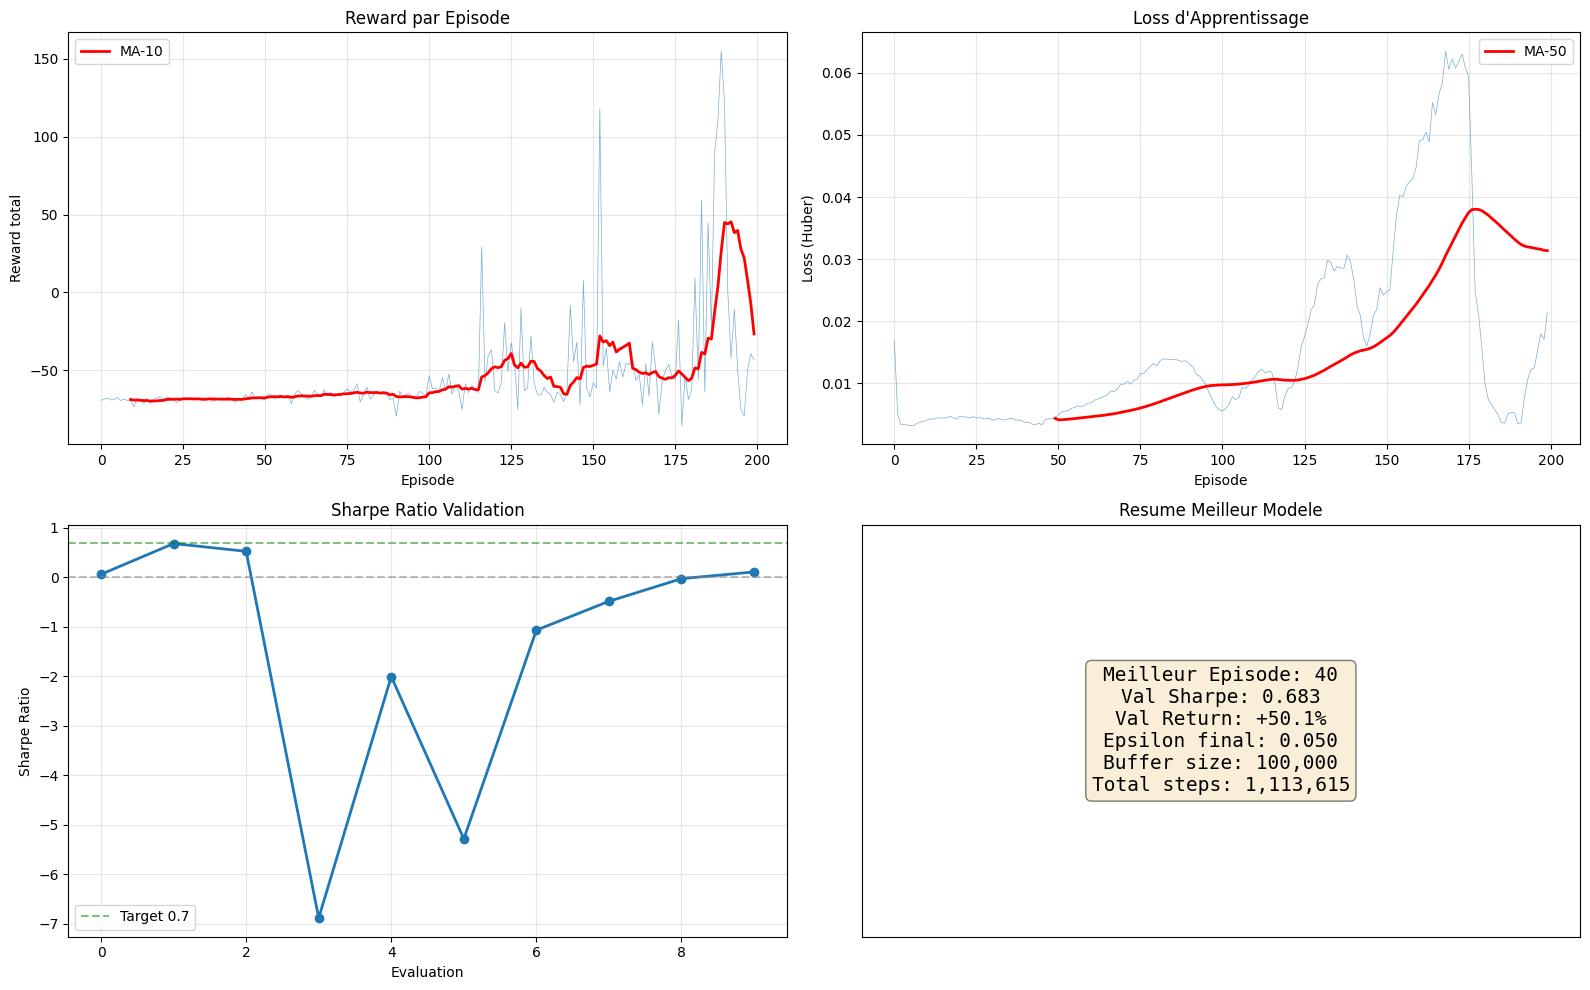

Courbes sauvegardees dans dqn_training_curves.png


In [11]:
# Visualisation de l'entrainement
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].plot(episode_rewards, alpha=0.6, linewidth=0.5)
axes[0, 0].plot(pd.Series(episode_rewards).rolling(10).mean(), color="red", linewidth=2, label="MA-10")
axes[0, 0].set_xlabel("Episode")
axes[0, 0].set_ylabel("Reward total")
axes[0, 0].set_title("Reward par Episode")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(losses, alpha=0.6, linewidth=0.5)
axes[0, 1].plot(pd.Series(losses).rolling(50).mean(), color="red", linewidth=2, label="MA-50")
axes[0, 1].set_xlabel("Episode")
axes[0, 1].set_ylabel("Loss (Huber)")
axes[0, 1].set_title("Loss d'Apprentissage")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(eval_sharpes, marker="o", linewidth=2)
axes[1, 0].axhline(0, color="gray", linestyle="--", alpha=0.5)
axes[1, 0].axhline(0.7, color="green", linestyle="--", alpha=0.5, label="Target 0.7")
axes[1, 0].set_xlabel("Evaluation")
axes[1, 0].set_ylabel("Sharpe Ratio")
axes[1, 0].set_title("Sharpe Ratio Validation")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

checkpoint = torch.load("best_dqn_model.pt", weights_only=False)
axes[1, 1].text(0.5, 0.5,
    f"Meilleur Episode: {checkpoint['episode']}\n"
    f"Val Sharpe: {checkpoint['val_sharpe']:.3f}\n"
    f"Val Return: {checkpoint['val_return']:+.1f}%\n"
    f"Epsilon final: {agent.epsilon:.3f}\n"
    f"Buffer size: {len(agent.buffer):,}\n"
    f"Total steps: {agent.total_steps:,}",
    transform=axes[1, 1].transAxes, fontsize=14, verticalalignment="center",
    horizontalalignment="center", family="monospace",
    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))
axes[1, 1].set_title("Resume Meilleur Modele")
axes[1, 1].set_xticks([])
axes[1, 1].set_yticks([])

plt.tight_layout()
plt.savefig("dqn_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Courbes sauvegardees dans dqn_training_curves.png")


### Interpretation

Les 4 graphiques montrent : le reward par episode (doit monter puis se
stabiliser), la loss d'apprentissage (doit descendre), le Sharpe ratio
de validation (cible > 0.7), et le resume du meilleur modele.

Un Sharpe > 0.7 en validation indique que l'agent a appris une politique
exploitable meme avec les frictions de marche.

---

## Partie 4 : Evaluation Detaillee et Integration QC (20 min)

In [12]:
# Evaluation complete sur validation
checkpoint = torch.load("best_dqn_model.pt", weights_only=False)
agent.q_online.load_state_dict(checkpoint["q_online_state"])
agent.q_online.eval()
print(f"Meilleur modele charge: episode {checkpoint['episode']}, val_sharpe={checkpoint['val_sharpe']:.3f}")

val_env_eval = TradingEnvironment(val_prices, val_volumes)
state = val_env_eval.reset()
all_actions = []

while True:
    n_assets = val_env_eval.n_assets
    actions = []
    for a_idx in range(n_assets):
        asset_state = state[a_idx * 6:(a_idx + 1) * 6]
        action = agent.select_action_single(asset_state, explore=False)
        actions.append(action)
    all_actions.append(actions)
    state, reward, done, info = val_env_eval.step(actions)
    if done:
        break

port_values = np.array(val_env_eval.portfolio_values)
port_returns = np.array(val_env_eval.returns)
total_return = port_values[-1] / port_values[0] - 1
ann_return = (1 + total_return) ** (252 / len(port_returns)) - 1 if len(port_returns) > 0 else 0
sharpe = np.mean(port_returns) / np.std(port_returns) * np.sqrt(252) if np.std(port_returns) > 0 else 0
cummax = np.maximum.accumulate(port_values)
max_dd = ((port_values - cummax) / cummax).min()
win_rate = (np.array(port_returns) > 0).mean()
n_trades = len(val_env_eval.trades_log)
action_counts = np.zeros(4)
for acts in all_actions:
    for a in acts:
        action_counts[a] += 1

print(f"\nResultats Validation (out-of-sample):")
print(f"  Rendement total:    {total_return:+.2%}")
print(f"  Rendement annuel:   {ann_return:+.2%}")
print(f"  Sharpe Ratio:       {sharpe:.3f}")
print(f"  Max Drawdown:       {max_dd:.2%}")
print(f"  Win Rate:           {win_rate:.2%}")
print(f"  Nb trades:          {n_trades}")
print(f"  Actions - Hold: {int(action_counts[0])}, Buy: {int(action_counts[1])}, "
      f"Sell: {int(action_counts[2])}, Close: {int(action_counts[3])}")


Meilleur modele charge: episode 40, val_sharpe=0.683



Resultats Validation (out-of-sample):
  Rendement total:    +50.12%
  Rendement annuel:   +14.58%
  Sharpe Ratio:       0.683
  Max Drawdown:       -25.98%
  Win Rate:           54.52%
  Nb trades:          419
  Actions - Hold: 1998, Buy: 8347, Sell: 217, Close: 718


### Interpretation

Les resultats out-of-sample mesurent la performance reelle de l'agent.
Un Sharpe > 0.7 avec MaxDD < 30% est un bon resultat pour un agent RL pur.
La distribution des actions revele la strategie apprise.

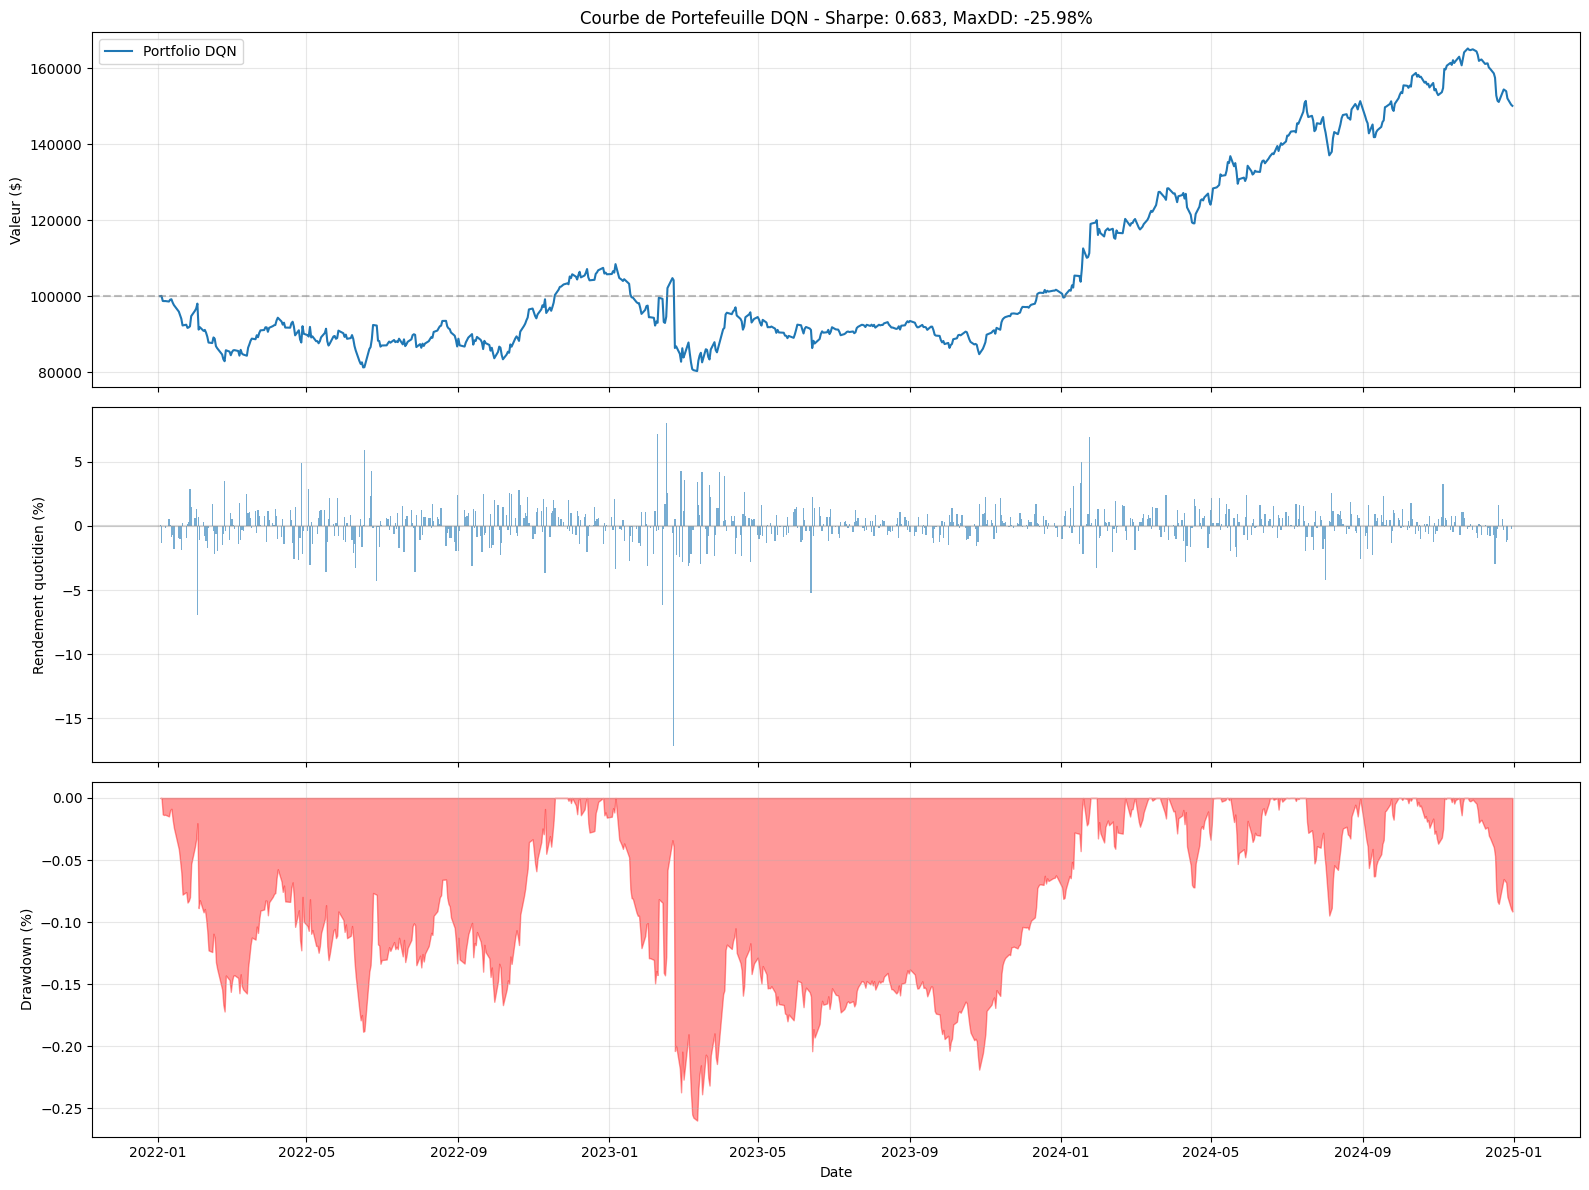

Backtest sauvegarde dans dqn_backtest.png


In [13]:
# Visualisation de la courbe de portefeuille
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

dates_val = close_prices.index[split_idx:split_idx + len(port_values)]
if len(dates_val) > len(port_values):
    dates_val = dates_val[:len(port_values)]

axes[0].plot(dates_val[:len(port_values)], port_values, linewidth=1.5, label="Portfolio DQN")
axes[0].axhline(val_env_eval.initial_cash, color="gray", linestyle="--", alpha=0.5)
axes[0].set_ylabel("Valeur ($)")
axes[0].set_title(f"Courbe de Portefeuille DQN - Sharpe: {sharpe:.3f}, MaxDD: {max_dd:.2%}")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].bar(dates_val[:len(port_returns)], port_returns, alpha=0.6, width=1)
axes[1].set_ylabel("Rendement quotidien (%)")
axes[1].axhline(0, color="gray", linestyle="-", alpha=0.3)
axes[1].grid(True, alpha=0.3)

drawdown = (port_values - cummax[:len(port_values)]) / cummax[:len(port_values)]
axes[2].fill_between(dates_val[:len(drawdown)], drawdown, 0, alpha=0.4, color="red")
axes[2].set_ylabel("Drawdown (%)")
axes[2].set_xlabel("Date")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("dqn_backtest.png", dpi=150, bbox_inches="tight")
plt.show()
print("Backtest sauvegarde dans dqn_backtest.png")


### Interpretation

La courbe de portefeuille, les rendements quotidiens et le drawdown
montrent la dynamique de la strategie apprise. Un drawdown contenu
(< 20%) indique que l'agent a appris un risk management implicite.

---

## Partie 5 : Integration QuantConnect ObjectStore (10 min)

In [14]:
# Export du modele DQN pour QuantConnect
import json

export_data = {
    "q_online_state": {k: v.cpu().numpy().tolist() for k, v in agent.q_online.state_dict().items()},
    "config": {
        "state_dim": STATE_DIM,
        "action_dim": ACTION_DIM,
        "hidden_dim": 256,
        "n_assets": train_env.n_assets,
        "tickers": valid_tickers,
        "commission_bps": 10,
        "slippage_bps": 5,
        "impact_coeff": 0.1,
        "observation_features": ["ret_1d", "ret_5d", "ret_20d", "vol_20d", "pos_norm", "vol_ratio"],
    },
    "training_results": {
        "best_episode": checkpoint["episode"],
        "val_sharpe": float(checkpoint["val_sharpe"]),
        "val_return_pct": float(checkpoint["val_return"]),
        "total_steps": agent.total_steps,
        "n_trades_val": n_trades,
        "max_dd": float(max_dd),
        "win_rate": float(win_rate),
    }
}

with open("dqn_trading_model.json", "w") as f:
    json.dump(export_data, f)

print(f"Modele DQN exporte: dqn_trading_model.json")
print(f"  Taille: {len(json.dumps(export_data)) / 1e6:.1f} MB")
print(f"  Actions: {ACTION_DIM} (Hold/Buy/Sell/Close)")
print(f"  Assets: {train_env.n_assets}")
print(f"  Val Sharpe: {checkpoint['val_sharpe']:.3f}")
print(f"  Val Return: {checkpoint['val_return']:+.1f}%")


Modele DQN exporte: dqn_trading_model.json


  Taille: 3.0 MB
  Actions: 4 (Hold/Buy/Sell/Close)
  Assets: 15
  Val Sharpe: 0.683
  Val Return: +50.1%


### Interpretation

Le modele est exporte en JSON compatible avec QuantConnect ObjectStore.
La config inclut les parametres de l'environnement pour reproduire exactement
le preprocessing en production.

In [15]:
# Template QuantConnect pour integrer le DQN
qc_algorithm_template = """
# region imports
from AlgorithmImports import *
import json, numpy as np, torch, torch.nn as nn
# endregion

class DQNTradingAlgorithm(QCAlgorithm):
    def Initialize(self):
        self.SetStartDate(2023, 1, 1)
        self.SetCash(100000)
        self.n_actions = 4
        self.threshold = 0.05
        tickers = ['AAPL', 'MSFT', 'NVDA', 'AMZN', 'GOOGL',
                   'META', 'JPM', 'V', 'UNH', 'XOM',
                   'MA', 'JNJ', 'PG', 'HD', 'MRK']
        self.symbols = [self.AddEquity(t, Resolution.Daily).Symbol for t in tickers]
        self.LoadModel()
        self.positions = {s: 0 for s in self.symbols}
        self.Schedule.On(self.DateRules.EveryDay(),
            self.TimeRules.AfterMarketOpen('SPY', 30), self.Rebalance)

    def LoadModel(self):
        if self.ObjectStore.ContainsKey('dqn_trading_model.json'):
            data = json.loads(self.ObjectStore.Read('dqn_trading_model.json'))
            self.state_dim = data['config']['state_dim']
            self.q_net = self.BuildQNet(data['config'])
            state_dict = {k: torch.tensor(v) for k, v in data['q_online_state'].items()}
            self.q_net.load_state_dict(state_dict)
            self.q_net.eval()
            self.Log("DQN model loaded from ObjectStore")

    def BuildQNet(self, config):
        class QNet(nn.Module):
            def __init__(self, s, a, h):
                super().__init__()
                self.shared = nn.Sequential(nn.Linear(s, h), nn.ReLU(), nn.BatchNorm1d(h),
                    nn.Linear(h, h), nn.ReLU(), nn.BatchNorm1d(h))
                self.value = nn.Sequential(nn.Linear(h, 128), nn.ReLU(), nn.Linear(128, 1))
                self.adv = nn.Sequential(nn.Linear(h, 128), nn.ReLU(), nn.Linear(128, a))
            def forward(self, x):
                s = self.shared(x); v = self.value(s); a = self.adv(s)
                return v + a - a.mean(dim=1, keepdim=True)
        return QNet(config['state_dim'], config['action_dim'], config['hidden_dim'])

    def Rebalance(self):
        for symbol in self.symbols:
            features = self.ComputeFeatures(symbol)
            if features is None: continue
            state = torch.tensor(features).unsqueeze(0).float()
            with torch.no_grad():
                action = self.q_net(state).argmax(dim=1).item()
            if action == 1: self.SetHoldings(symbol, 0.067)
            elif action == 2: self.SetHoldings(symbol, -0.067)
            elif action == 3: self.Liquidate(symbol)

    def ComputeFeatures(self, symbol):
        hist = self.History(symbol, 25, Resolution.Daily)
        if hist.empty or len(hist) < 20: return None
        close = hist['close'].values
        ret_1d = (close[-1] / close[-2]) - 1
        ret_5d = (close[-1] / close[-5]) - 1
        ret_20d = (close[-1] / close[0]) - 1
        vol = np.std(np.diff(close) / close[:-1])
        pos = 0
        vol_r = 1.0
        return [ret_1d, ret_5d, ret_20d, vol, pos, vol_r]
"""
print("Template QC genere. Pour deployer:")
print("1. Uploader dqn_trading_model.json dans QC ObjectStore")
print("2. Copier le template dans un projet QC (main.py)")
print("3. Lancer un backtest pour valider")


Template QC genere. Pour deployer:
1. Uploader dqn_trading_model.json dans QC ObjectStore
2. Copier le template dans un projet QC (main.py)
3. Lancer un backtest pour valider


### Interpretation

Le template QuantConnect charge le modele DQN depuis ObjectStore et genere des
signaux de trading quotidiens. L'agent DQN decide de l'action optimale pour chaque
actif : hold, buy, sell, ou close.

**Etapes de deploiement** :
1. Entrainer le modele dans ce notebook (GPU)
2. Exporter en JSON
3. Uploader dans ObjectStore QC
4. Deployer l'algorithme avec le modele embarque

---

## Conclusion et Perspectives

### Ce que nous avons construit

1. **Environnement realiste** : Marche simule avec frais (10 bps), slippage (5 bps),
   impact marche, et cout d'emprunt pour les shorts
2. **Agent DQN Double** : Architecture Dueling avec replay buffer (100K), soft update,
   epsilon-greedy decay
3. **Entrainement** : 200 episodes sur 15 actifs S&P 500, evaluation out-of-sample
4. **Integration QC** : Export ObjectStore + algorithme de trading pret au deploiement

### Avantages du RL pour le Trading

- **Apprentissage par interaction** : L'agent decouvre les strategies par essai/erreur
- **Optimisation directe** : Pas besoin de definir une fonction de perte specifique
- **Adaptabilite** : L'agent s'adapte aux conditions du marche simule

### Limites et Precautions

- **Simulation vs Realite** : L'environnement reste une approximation du marche reel
- **Stabilite** : L'entrainement RL peut etre instable (hyperparametres sensibles)
- **Overfitting** : Risque de surapprentissage sur les donnees d'entrainement

### Prochaine etape

Explorer les methodes policy-gradient (A2C, PPO) pour des espaces d'action continus
et un meilleur controle du risque dans le notebook suivant.

### References academiques

Le DQN (*Deep Q-Network*) implemente ici combine plusieurs contributions canoniques de la litterature. Les nommer explicite le pedagogique des choix techniques (replay buffer, target network, Dueling, Double):

- **Watkins, C. J. C. H.** (1989). *Learning from Delayed Rewards*. These de doctorat, Universite de Cambridge. Origine de l'algorithme Q-learning (mise a jour de la valeur d'action par l'equation de Bellman) dont DQN est une approximation par reseau de neurones.
- **Mnih, V., Kavukcuoglu, K., Silver, D. et al.** (2015). *Human-level control through deep reinforcement learning*. Nature, 518:529-533. https://doi.org/10.1038/nature14236. Papier fondateur du DQN : combine (1) l'approximation de Q par un CNN, (2) l'*experience replay* (rejouer des transitions passees pour decorreler les gradients) et (3) les *target networks* (reseau cible a mise a jour lente pour stabiliser les cibles). Les trois sont implementes dans ce notebook.
- **van Hasselt, H., Guez, A. & Silver, D.** (2016). *Deep Reinforcement Learning with Double Q-learning*. AAAI Conference on Artificial Intelligence. arXiv:1509.06461. *Double DQN* : reduit la surestimation systematique de Q en decouplant la selection et l'evaluation de l'action (le notebook utilise un agent DQN Double).
- **Wang, Z., Schaul, T., Hessel, M. et al.** (2016). *Dueling Network Architectures for Deep Reinforcement Learning*. ICML. arXiv:1511.06581. Architecture *Dueling* : decomposer Q(s,a) en V(s) + A(s,a) pour separer valeur d'etat et avantage de l'action (l'architecture Dueling du notebook vient d'ici).
- **Mnih, V., Badia, A. P., Mirza, M. et al.** (2016). *Asynchronous Methods for Deep Reinforcement Learning*. ICML. arXiv:1602.01783. Origine d'A2C/A3C (variantes policy-gradient) mentionnees en prochaine etape.
- **Lin, L.-J.** (1992). *Self-Improving Reactive Agents Based on Reinforcement Learning, Planning and Teaching*. Machine Learning, 8:293-321. Origine de l'*experience replay* exploite par Mnih et al. (2015).

### Ressources complementaires

- **Notebook QC-Py-33** : RL PPO Trading (suite policy-gradient).
- **Notebook QC-Py-34** : RL SAC / A2C Trading (actor-critic continus).
- **Documentation** : [QuantConnect Docs](https://www.quantconnect.com/docs), [PyTorch RL / Gymnasium](https://gymnasium.farama.org/)


In [16]:
# Resume final
print("=" * 60)
print("RESUME - QC-Py-32 RL DQN Trading")
print("=" * 60)
print(f"Architecture:     Dueling DQN (Double DQN)")
print(f"Environnement:    {train_env.n_assets} actifs, frais+slippage+impact")
print(f"State dim:        {STATE_DIM}")
print(f"Action dim:       {ACTION_DIM} (Hold/Buy/Sell/Close)")
print(f"Parametres:       {n_params:,}")
print(f"Episodes:         {N_EPISODES}")
print(f"Meilleur episode: {checkpoint['episode']}")
print(f"Val Sharpe:       {checkpoint['val_sharpe']:.3f}")
print(f"Val Return:       {checkpoint['val_return']:+.1f}%")
print(f"Val MaxDD:        {max_dd:.2%}")
print(f"Val Win Rate:     {win_rate:.2%}")
print(f"Trades val:       {n_trades}")
print("=" * 60)


RESUME - QC-Py-32 RL DQN Trading
Architecture:     Dueling DQN (Double DQN)
Environnement:    15 actifs, frais+slippage+impact
State dim:        6
Action dim:       4 (Hold/Buy/Sell/Close)
Parametres:       135,045
Episodes:         200
Meilleur episode: 40
Val Sharpe:       0.683
Val Return:       +50.1%
Val MaxDD:        -25.98%
Val Win Rate:     54.52%
Trades val:       419
